In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from optbinning import ContinuousOptimalBinning

## Hàm hỗ trợ

In [28]:
def create_woe_df(x, y, splits):
    """
    Create WOE / IV table from manually specified or optimal splits.

    Parameters
    ----------
    x : pd.Series
        Feature values.
    y : pd.Series
        Binary target: 0 = non-event, 1 = event.
    splits : array-like
        Bin split points.

    Returns
    -------
    pd.DataFrame
        Bin, prob_n_obs, WOE, IV_detail, IV_total
    """

    # Make sure x/y have the same index
    data = pd.DataFrame({'x': x, 'target': y})
    bin_edges = [-np.inf] + list(splits) + [np.inf]
    data['bin'] = pd.cut(data['x'], bins=bin_edges, right=True, include_lowest=True)

    grouped = (data.groupby('bin', observed=False)['target']
        .agg(n_events=lambda s: (s == 1).sum(), n_non_events=lambda s: (s == 0).sum())
        .reset_index())

    missing_mask = data['x'].isna()

    if missing_mask.any():
        missing_row = pd.DataFrame({
            'bin': ['Missing'],
            'n_events': [(missing_mask & (data['target'] == 1)).sum()],
            'n_non_events': [(missing_mask & (data['target'] == 0)).sum()]
        })
        grouped = pd.concat([grouped, missing_row], ignore_index=True)

    total_obs = len(data)
    total_events = (data['target'] == 1).sum()
    total_non_events = (data['target'] == 0).sum()

    grouped['prob_n_obs'] = (grouped['n_events'] + grouped['n_non_events']) / total_obs
    grouped['pct_event'] = grouped['n_events'] / total_events if total_events > 0 else 0
    grouped['pct_non_event'] = grouped['n_non_events'] / total_non_events if total_non_events > 0 else 0

    eps = 1e-6
    pct_event_adj = np.where(grouped['pct_event'] == 0, eps, grouped['pct_event'])
    pct_non_event_adj = np.where(grouped['pct_non_event'] == 0, eps, grouped['pct_non_event'])

    grouped['WOE'] = np.log(pct_event_adj / pct_non_event_adj)
    grouped['IV_detail'] = (pct_event_adj - pct_non_event_adj) * grouped['WOE']
    grouped['IV_total'] = grouped['IV_detail'].sum()
    grouped['Bin'] = grouped['bin'].astype(str)

    return grouped[['Bin', 'prob_n_obs', 'pct_event', 'pct_non_event', 'WOE', 'IV_detail', 'IV_total']].copy()

In [29]:
def get_bin_stats(x, y, splits):
    """
    Return observation count and proportion for each bin.
    Missing values are excluded because x used for optimization
    has already removed missing values.
    """
    bin_edges = [-np.inf] + list(splits) + [np.inf]

    bins = pd.cut(x, bins=bin_edges, right=True, include_lowest=True)

    stats = (pd.DataFrame({'bin': bins, 'target': y})
        .groupby('bin', observed=False)
        .size()
        .reset_index(name='n_obs')
    )
    stats['prob_n_obs'] = stats['n_obs'] / len(x)
    return stats

In [30]:
def validate_splits(x, splits, min_n_bins, max_n_bins, min_bin_size, max_bin_size):
    """
    Validate manually edited split points.
    """

    splits = np.array(splits, dtype=float)

    # Check finite
    if not np.all(np.isfinite(splits)):
        return {'valid': False, 'message': 'Edited splits phải là các số finite.'}
    # Sort
    splits = np.sort(splits)
    # Check duplicate
    if len(np.unique(splits)) != len(splits):
        return {'valid': False, 'message': 'Edited splits chứa duplicate split point.'}

    n_bins = len(splits) + 1

    if n_bins < min_n_bins:
        return {
            'valid': False,
            'message': (
                f'Số bin = {n_bins}, nhỏ hơn min_n_bins = '
                f'{min_n_bins}.'
            )
        }

    if n_bins > max_n_bins:
        return {
            'valid': False,
            'message': (
                f'Số bin = {n_bins}, lớn hơn max_n_bins = '
                f'{max_n_bins}.'
            )
        }

    bin_stats = get_bin_stats(x=x, y=pd.Series(index=x.index, data=0), splits=splits)
    min_violation = bin_stats[bin_stats['prob_n_obs'] < min_bin_size].copy()

    max_violation = bin_stats[bin_stats['prob_n_obs'] > max_bin_size].copy()

    valid = (len(min_violation) == 0 and len(max_violation) == 0)

    return {
        'valid': valid,
        'n_bins': n_bins,
        'splits': splits,
        'bin_stats': bin_stats,
        'min_violation': min_violation,
        'max_violation': max_violation,
        'message': (
            'Edited splits hợp lệ.' if valid else 'Edited splits vi phạm bin-size constraint.'
        )
    }


In [31]:
def plot_raw_woe(x, y, feature='', n_bins=50, specialvalue=0, smoothing=0.5, splits_ref=None):
    data = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'), 'target': y}).copy()
    data = data[data['target'].isin([0, 1])].copy()
    if data.empty:
        return

    missing = data['x'].isna()
    special = data['x'].eq(specialvalue) if specialvalue is not None else pd.Series(False, index=data.index)
    numeric = ~(missing | special)
    x_numeric = data.loc[numeric, 'x']

    n_unique_num = x_numeric.nunique()

    if n_unique_num == 0:
        numeric_bins = pd.Series(pd.NA, index=data.index, dtype='object')
        bin_labels = []
    elif n_unique_num <= n_bins:
        values = np.sort(x_numeric.unique())
        numeric_bins = data['x'].map({v: str(v) for v in values}).where(numeric)
        bin_labels = [str(v) for v in values]
    else:
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(x_numeric.quantile(quantiles).to_numpy())
        if len(edges) < 2:
            numeric_bins = data['x'].map({x_numeric.iloc[0]: str(x_numeric.iloc[0])}).where(numeric)
            bin_labels = [str(x_numeric.iloc[0])]
        else:
            numeric_bins = pd.cut(data['x'], bins=edges, include_lowest=True, right=True)
            bin_labels = [str(v) for v in numeric_bins.dropna().unique()]
            bin_labels = sorted(bin_labels, key=lambda z: float(z.split(',')[0].strip('([')))

    data['_bin_'] = numeric_bins.astype(object)
    data.loc[missing, '_bin_'] = 'MISSING'
    data.loc[special, '_bin_'] = 'ZERO'

    grouped = data.groupby('_bin_', dropna=False)['target'].agg(
        n_obs='count',
        n_card='sum'
    ).reset_index()

    grouped['n_non_card'] = grouped['n_obs'] - grouped['n_card']

    total_card = grouped['n_card'].sum()
    total_non_card = grouped['n_non_card'].sum()
    n_categories = len(grouped)

    grouped['pct_card'] = grouped['n_card'] / total_card if total_card > 0 else 0
    grouped['pct_non_card'] = grouped['n_non_card'] / total_non_card if total_non_card > 0 else 0

    grouped['pct_card_smooth'] = (grouped['n_card'] + smoothing) / (total_card + smoothing * n_categories)
    grouped['pct_non_card_smooth'] = (grouped['n_non_card'] + smoothing) / (total_non_card + smoothing * n_categories)
    grouped['WOE'] = np.log(grouped['pct_card_smooth'] / grouped['pct_non_card_smooth'])
    grouped['pct_obs'] = grouped['n_obs'] / len(data)

    def sort_key(value):
        if value == 'MISSING':
            return (-2, 0.0)
        if value == 'ZERO':
            return (-1, 0.0)
        try:
            if isinstance(value, str) and value.startswith(('(', '[')):
                left = value.split(',')[0].strip('([')
                return (0, float(left))
            return (0, float(value))
        except (ValueError, TypeError):
            return (1, 0.0)

    grouped['_sort'] = grouped['_bin_'].apply(sort_key)
    grouped = grouped.sort_values('_sort').reset_index(drop=True).drop(columns='_sort')

    x_pos = np.arange(len(grouped))
    labels = grouped['_bin_'].astype(str).tolist()
    missing_mask = grouped['_bin_'].eq('MISSING')
    zero_mask = grouped['_bin_'].eq('ZERO')

    fig, ax_woe = plt.subplots(figsize=(15, 6))
    ax_obs = ax_woe.twinx()

    ax_obs.bar(x_pos, grouped['pct_obs'], width=0.85, color='#5B9BD5', alpha=0.28, label='% Obs', zorder=1)
    ax_woe.plot(x_pos, grouped['WOE'], color='green', marker='o', markersize=4, linewidth=1.3, linestyle='--', label='WOE', zorder=3)

    if missing_mask.any():
        ax_woe.scatter(x_pos[missing_mask], grouped.loc[missing_mask, 'WOE'], color='red', s=45, zorder=4)

    if zero_mask.any():
        ax_woe.scatter(x_pos[zero_mask], grouped.loc[zero_mask, 'WOE'], color='orange', s=45, zorder=4)

    ax_woe.axhline(0, color='red', linestyle=':', linewidth=1)
    ax_woe.set_ylabel('WOE', color='green')
    ax_woe.tick_params(axis='y', labelcolor='green')
    ax_obs.set_ylabel('% Observations', color='#5B9BD5')
    ax_obs.tick_params(axis='y', labelcolor='#5B9BD5')
    ax_obs.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

    if splits_ref is not None and n_unique_num > n_bins and len(x_numeric) > 0:
        for split in splits_ref:
            if x_numeric.min() < split < x_numeric.max():
                idx = np.searchsorted(x_numeric.quantile(np.linspace(0, 1, n_bins + 1)).to_numpy(), split, side='right') - 1
                idx = max(0, min(idx, len(x_pos) - 1))
                ax_woe.axvline(idx, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

    ax_woe.set_xticks(x_pos)
    ax_woe.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax_woe.set_xlabel(feature)
    ax_woe.set_title(f'Weight of Evidence by {feature} (n_categories={len(grouped)})')
    ax_woe.grid(axis='y', alpha=0.15)

    handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
    handles_obs, labels_obs = ax_obs.get_legend_handles_labels()
    ax_woe.legend(handles_woe + handles_obs, labels_woe + labels_obs, loc='upper left')

    plt.tight_layout()
    plt.show()

In [32]:
def plot_three_options(results, feature, x, y):
    """
    Compare 3 optimal binning strategies.

    Each subplot:
        - Left Y-axis  : WOE
        - Right Y-axis : Bin Count
        - X-axis       : Bin
    """

    fig, axes = plt.subplots(1, 3, figsize=(21, 6))

    for ax_woe, (option_name, result) in zip(axes, results.items()):
        splits = result['splits']
        woe_df = create_woe_df(x, y, splits)
        woe_plot = woe_df[woe_df['Bin'] != 'Missing'].copy()

        bin_stats = get_bin_stats(x=x, y=y, splits=splits)

        n_bins = len(bin_stats)
        x_pos = np.arange(n_bins)

        ax_woe.plot(x_pos, woe_plot['WOE'].values, marker='o', linewidth=2, label='WOE')
        ax_woe.axhline(0, linestyle='--', linewidth=1)

        ax_woe.set_ylabel('WOE')
        ax_woe.set_xlabel('Bin')

        ax_woe.set_xticks(x_pos)
        ax_woe.set_xticklabels(bin_stats['bin'].astype(str), rotation=45, ha='right')
        ax_woe.grid(axis='y', alpha=0.3)

        ax_count = ax_woe.twinx()
        ax_count.bar(x_pos, bin_stats['n_obs'].values, alpha=0.25, width=0.6, label='Bin Count')
        ax_count.set_ylabel('Bin Count')

        ax_woe.set_title(option_name, fontsize=12)

        handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
        handles_count, labels_count = ax_count.get_legend_handles_labels()

        ax_woe.legend(handles_woe + handles_count, labels_woe + labels_count, loc='best', fontsize=8)

    fig.suptitle(f'{feature} - WOE Trend & Bin Count Comparison', fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

In [33]:
def plot_woe_onsplits(df, x, y, splits):
    bin_stats = get_bin_stats(x=x, y=y_clean, splits=splits)

    woe_plot = df[df['Bin'] != 'Missing'].copy()

    x_pos = np.arange(len(woe_plot))
    fig, ax_woe = plt.subplots(figsize=(7, 4))

    ax_woe.plot(x_pos, woe_plot['WOE'], marker='o', linewidth=2, label='WOE')
    ax_woe.axhline(0, linestyle='--', linewidth=1)

    ax_woe.set_xlabel('Bin')
    ax_woe.set_ylabel('WOE')
    ax_woe.set_xticks(x_pos)
    ax_woe.set_xticklabels(woe_plot['Bin'], rotation=30, ha='right')
    ax_woe.grid(axis='y', alpha=0.3)

    ax_count = ax_woe.twinx()
    ax_count.bar(x_pos, bin_stats['n_obs'], alpha=0.25, width=0.6, label='Bin Count')

    ax_count.set_ylabel('Bin Count')
    ax_woe.set_title(f'{feature} - Edited Split')

    handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
    handles_count, labels_count = ax_count.get_legend_handles_labels()

    ax_woe.legend(handles_woe + handles_count, labels_woe + labels_count, loc='best')

    plt.tight_layout()
    plt.show()

In [34]:


def _woe_trend(woe):
    woe = pd.to_numeric(woe, errors='coerce').dropna().to_numpy()

    if len(woe) < 3:
        return 'no_clear_trend'

    diff = np.diff(woe)
    diff = diff[diff != 0]

    if len(diff) == 0:
        return 'no_clear_trend'

    signs = np.sign(diff)

    if np.all(signs > 0) or np.all(signs < 0):
        return 'monotonic'

    changes = np.where(signs[1:] != signs[:-1])[0]

    if len(changes) == 1:
        i = changes[0]

        if signs[i] < 0 and signs[i + 1] > 0:
            return 'u_shape'

        if signs[i] > 0 and signs[i + 1] < 0:
            return 'inverted_u_shape'

    return 'no_clear_trend'


def compare_woe_tables(old_df,new_df,thresholds=(0.5,0.3,0.1,0.02)):
    old = old_df.copy().reset_index(drop=True)
    new = new_df.copy().reset_index(drop=True)

    old_iv_total = old['IV_total'].iloc[0]
    new_iv_total = new['IV_total'].iloc[0]
    iv_total_gap = new_iv_total - old_iv_total

    if iv_total_gap > 0:
        iv_total_direction = 'increased'
    elif iv_total_gap < 0:
        iv_total_direction = 'decreased'
    else:
        iv_total_direction = 'unchanged'

    old_trend = _woe_trend(old['WOE'])
    new_trend = _woe_trend(new['WOE'])

    trend_summary = pd.DataFrame({
        'table': ['old', 'edit'],
        'WOE_trend': [old_trend, new_trend]
    })

    if len(old) != len(new):
        raise ValueError(
            f'Old and edit must have the same number of bins: '
            f'old={len(old)}, edit={len(new)}'
        )

    iv_comparison = pd.DataFrame({
        'bin_order': np.arange(1,len(old) + 1),
        'Bin_old': old['Bin'],
        'Bin_new': new['Bin'],
        'IV_old': old['IV_detail'],
        'IV_new': new['IV_detail']
    })

    iv_comparison['gap'] = iv_comparison['IV_new'] - iv_comparison['IV_old']
    # iv_comparison['abs_gap'] = iv_comparison['gap'].abs()

    threshold_changes = []

    for threshold in thresholds:
        for _, row in iv_comparison.iterrows():
            old_iv = row['IV_old']
            new_iv = row['IV_new']

            old_above = old_iv >= threshold
            new_above = new_iv >= threshold

            if old_above != new_above:
                threshold_changes.append({
                    'bin_order': row['bin_order'],
                    'Bin_old': row['Bin_old'],
                    'Bin_new': row['Bin_new'],
                    'threshold': threshold,
                    'IV_old': old_iv,
                    'IV_new': new_iv,
                    'gap': row['gap'],
                    # 'abs_gap': row['abs_gap'],
                    'change': f"{'below' if old_iv < threshold else 'above'} -> {'above' if new_iv >= threshold else 'below'}"
                })

    threshold_changes = pd.DataFrame(threshold_changes)

    return {
        'iv_total': {
            'old': old_iv_total,
            'edit': new_iv_total,
            'gap': iv_total_gap,
            'abs_gap': abs(iv_total_gap),
            'direction': iv_total_direction
        },
        'woe_trend': trend_summary,
        'iv_bin_comparison': iv_comparison,
        'threshold_changes': threshold_changes
    }

## Đọc file csv

In [35]:
df = pd.read_csv('train_sdf_selected1.csv')

X_train = df.drop(columns=['LABEL'])
y = pd.Series(df['LABEL'].values, index=X_train.index)
print('Data features:')
df.columns

Data features:


Index(['A', 'B', 'C', 'D', 'LABEL'], dtype='str')

## Chọn biến cần tính

In [36]:
feature = "A"

In [37]:
x = X_train[feature].copy()

Chọn max_bin (không cần chỉnh, có thể giảm nếu cần)

In [38]:
min_bin = 4
max_bin = 10

### Tính lại min, max bin size
Vì drop missing và ZERO nên tỉ lệ ràng buộc 5% < x < 50% sẽ thay đổi

In [39]:
specialvalue = 0

In [40]:

# Calculate proportion of zero values
zero_pct = (x == specialvalue).mean()

# Include (x != 0) only if zeros make up 5% or more of the series
if zero_pct < 0.05:
    print('Not split zero')
    mask_nonmissing = x.notna()
else:
    print('Split zero')
    mask_nonmissing = x.notna() & (x != specialvalue)

x = x.loc[mask_nonmissing]
y_clean = y.loc[mask_nonmissing]

n_old = len(X_train)
n_missing = X_train[feature].isna().sum()
n_zero = (X_train[feature] == 0).sum()
n_new = len(x)

min_bin_size = 0.05 * n_old / n_new
max_bin_size = min(0.50 * n_old / n_new, 1)

Not split zero


In [41]:
print('Original observations:', n_old)
print('Missing:', n_missing)
print('Zero:', n_zero)
print('Clean observations:', n_new)
print('Min bin size:', min_bin_size)
print('Max bin size:',max_bin_size)


Original observations: 64343
Missing: 43443
Zero: 0
Clean observations: 20900
Min bin size: 0.1539306220095694
Max bin size: 1


## 3 tùy chọn tính WOE

In [42]:
options = {
    '1. Free optimization': 'auto',
    '2. Monotonic': 'auto_asc_desc',
    '3. U-shape / heuristic': 'auto_heuristic'
}


In [43]:
results = {}

for option_name, trend in options.items():
    optb = ContinuousOptimalBinning(
        name=feature,
        dtype="numerical",
        min_n_bins=min_bin,
        max_n_bins=max_bin,
        min_bin_size=min_bin_size,
        max_bin_size=max_bin_size,
        monotonic_trend=trend
    )
    optb.fit(x, y_clean)
    results[option_name] = {
        'model': optb,
        'splits': optb.splits,
        'binning_table': optb.binning_table
    }



### Trạng thái giải xu hướng WOE 
OPTIMAL - Giải thành công \
INFEASIBLE - Không giải được

In [44]:
print('OPTIMAL SPLITS')

for option_name, result in results.items():
    print(f'\n{option_name}')
    print('Status:', result['model'].status)
    print('Optimal splits:', list(map(float, result['splits'])))



OPTIMAL SPLITS

1. Free optimization
Status: OPTIMAL
Optimal splits: [3.5, 10.5, 57.5]

2. Monotonic
Status: OPTIMAL
Optimal splits: [3.5, 13.5, 57.5]

3. U-shape / heuristic
Status: OPTIMAL
Optimal splits: [3.5, 10.5, 57.5]


### Biểu đồ WOE ở 3 configs

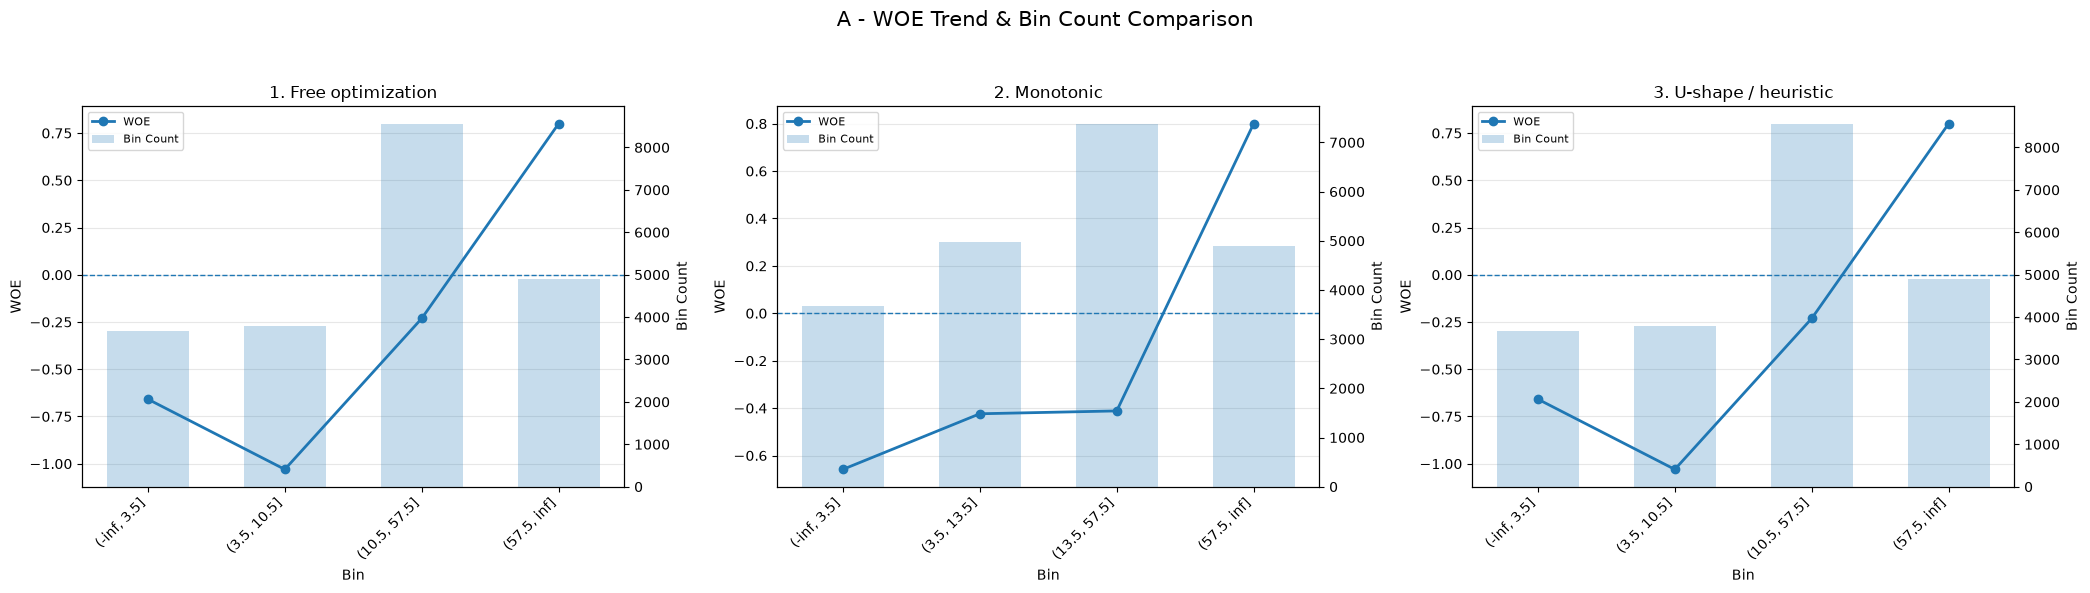

In [45]:
plot_three_options(results, feature,x, y_clean)


### Bảng thông tin WOE và IV

In [46]:
print('WOE TABLES')
woe_tables = {}
for option_name, result in results.items():
    print(option_name)
    splits = result['splits']
    woe_df = create_woe_df(x, y_clean, splits)
    woe_tables[option_name] = woe_df
    display(
        woe_df.style.format({'prob_n_obs': '{:.2%}', 'WOE': '{:.4f}',
            'IV_detail': '{:.4f}', 'IV_total': '{:.4f}'})
    )

WOE TABLES
1. Free optimization


,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",17.53%,0.090909,0.175623,-0.6585,0.0558,0.4247
1,"(3.5, 10.5]",18.15%,0.064935,0.181914,-1.0301,0.1205,0.4247
2,"(10.5, 57.5]",40.88%,0.324675,0.409067,-0.2311,0.0195,0.4247
3,"(57.5, inf]",23.44%,0.519481,0.233396,0.8001,0.2289,0.4247


2. Monotonic


,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",17.53%,0.090909,0.175623,-0.6585,0.0558,0.3686
1,"(3.5, 13.5]",23.78%,0.155844,0.238102,-0.4238,0.0349,0.3686
2,"(13.5, 57.5]",35.24%,0.233766,0.352879,-0.4118,0.0491,0.3686
3,"(57.5, inf]",23.44%,0.519481,0.233396,0.8001,0.2289,0.3686


3. U-shape / heuristic


,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",17.53%,0.090909,0.175623,-0.6585,0.0558,0.4247
1,"(3.5, 10.5]",18.15%,0.064935,0.181914,-1.0301,0.1205,0.4247
2,"(10.5, 57.5]",40.88%,0.324675,0.409067,-0.2311,0.0195,0.4247
3,"(57.5, inf]",23.44%,0.519481,0.233396,0.8001,0.2289,0.4247


## Tùy chỉnh khoảng bin 
Comment/uncomment để chọn option

In [47]:
chosen_option = '1. Free optimization'
# setting = '2. Monotonic'
# setting = '3. U-shape / heuristic'

chosensplit = [float(x) for x in results[chosen_option]['splits']]

Khoảng chia bin gốc được chọn

In [48]:
print(chosensplit)

[3.5, 10.5, 57.5]


Copy bin gốc phía trên và Chỉnh sửa bin

In [49]:
edited_splits = [4, 11, 58]

Kiểm tra bin mới có hợp lệ hay không? Nếu không thỏa điều kiện, sẽ raise lỗi

In [50]:
validation = validate_splits(x=x, splits=edited_splits, min_n_bins=4, max_n_bins=max_bin, min_bin_size=min_bin_size, max_bin_size=max_bin_size)

print(f"Edited splits: {edited_splits}")
print(f"Number of bins: {validation.get('n_bins')}")

if not validation['valid']:
    print("Result: Edited splits không hợp lệ.")

    if validation.get('n_bins', 0) < 4:
        print(f"- Số bin = {validation['n_bins']}, nhỏ hơn min_n_bins = 4.")
    elif validation.get('n_bins', 0) > max_bin:
        print(f"- Số bin = {validation['n_bins']}, lớn hơn max_n_bins = {max_bin}.")

    min_violation = validation.get('min_violation', pd.DataFrame())
    if not min_violation.empty:
        print(f"- Các bin có prob_n_obs < min_bin_size ({min_bin_size:.2%}) (5% data gốc):")
        display(min_violation.style.format({'prob_n_obs': '{:.2%}'}))

    max_violation = validation.get('max_violation', pd.DataFrame())
    if not max_violation.empty:
        print(f"- Các bin có prob_n_obs > max_bin_size ({max_bin_size:.2%}) (50% data gốc):")
        display(max_violation.style.format({'prob_n_obs': '{:.2%}'}))

    raise ValueError("Hãy chỉnh lại edited_splits.")

print("Result: Edited splits hợp lệ.")
splits = validation['splits']
print(f"Valid edited splits: {list(map(float, splits))}")
# display(validation['bin_stats'].style.format({'prob_n_obs': '{:.2%}'}))

Edited splits: [4, 11, 58]
Number of bins: 4
Result: Edited splits hợp lệ.
Valid edited splits: [4.0, 11.0, 58.0]


### So sánh và đánh giá giữa bins gốc và mới

#### Kết quả gốc

Kết quả option gốc đang chọn


,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,"(-inf, 3.5]",17.53%,0.090909,0.175623,-0.6585,0.0558,0.4247
1,"(3.5, 10.5]",18.15%,0.064935,0.181914,-1.0301,0.1205,0.4247
2,"(10.5, 57.5]",40.88%,0.324675,0.409067,-0.2311,0.0195,0.4247
3,"(57.5, inf]",23.44%,0.519481,0.233396,0.8001,0.2289,0.4247


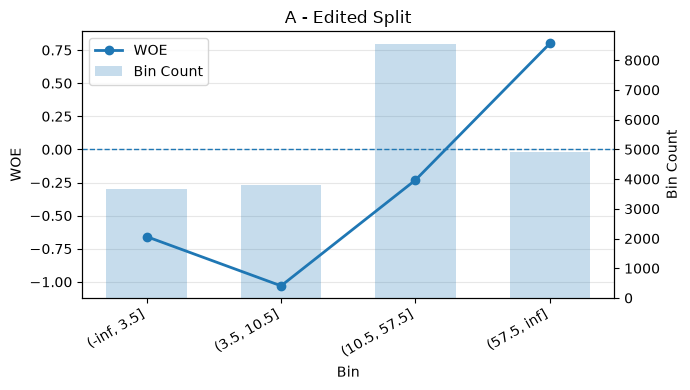

In [51]:
print('Kết quả option gốc đang chọn')

display(
    woe_tables[chosen_option].style.format({'prob_n_obs': '{:.2%}', 'WOE': '{:.4f}',
        'IV_detail': '{:.4f}', 'IV_total': '{:.4f}'})
)
plot_woe_onsplits(woe_tables[chosen_option], x,y_clean, chosensplit)

#### Kết quả mới

Kết quả WOE tùy chỉnh


,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,"(-inf, 4.0]",20.97%,0.090909,0.210104,-0.8377,0.0999,0.3452
1,"(4.0, 11.0]",16.65%,0.129870,0.166595,-0.2490,0.0091,0.3452
2,"(11.0, 58.0]",39.32%,0.285714,0.393555,-0.3202,0.0345,0.3452
3,"(58.0, inf]",23.07%,0.493506,0.229746,0.7646,0.2017,0.3452


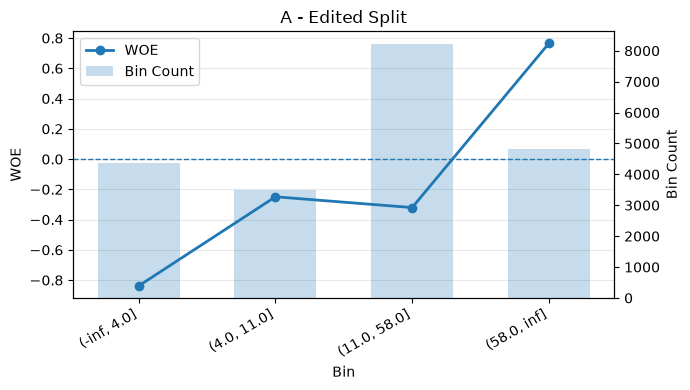

In [52]:
print('Kết quả WOE tùy chỉnh')
edited_woe_df = create_woe_df(x, y_clean, splits)

display(edited_woe_df.style.format({'prob_n_obs': '{:.2%}','WOE': '{:.4f}','IV_detail': '{:.4f}','IV_total': '{:.4f}'}))
plot_woe_onsplits(edited_woe_df, x,y_clean, splits)

#### Chênh lệch IV tổng

In [53]:
comparison = compare_woe_tables(
    woe_tables[chosen_option],
    edited_woe_df
)

In [54]:
iv = comparison['iv_total']
print(f"IV total gốc : {iv['old']:.6f}")
print(f"IV total mới : {iv['edit']:.6f}")
if iv['direction'] == 'increased':
    print(f"IV total mới TĂNG {iv['abs_gap']:.6f} so với cũ.")
elif iv['direction'] == 'decreased':
    print(f"IV total mới GIẢM {iv['abs_gap']:.6f} so với cũ.")
else:
    print("IV total mới KHÔNG THAY ĐỔI so với cũ.")

IV total gốc : 0.424682
IV total mới : 0.345195
IV total mới GIẢM 0.079486 so với cũ.


#### Kiểm tra lại xu hướng WOE

In [55]:
trend = comparison['woe_trend']

old_trend = trend.loc[trend['table'] == 'old', 'WOE_trend'].iloc[0]
edit_trend = trend.loc[trend['table'] == 'edit', 'WOE_trend'].iloc[0]

print(f"WOE trend gốc : {old_trend}")
print(f"WOE trend mới : {edit_trend}")

if old_trend == edit_trend:
    print(f"WOE trend không thay đổi: cả cũ và edit đều là {old_trend}.")
else:
    print(f"WOE trend thay đổi: {old_trend} -> {edit_trend}.")

WOE trend gốc : u_shape
WOE trend mới : no_clear_trend
WOE trend thay đổi: u_shape -> no_clear_trend.


#### Khác biệt theo từng bin theo cách chia gốc và cách chia mới

In [56]:
comparison['iv_bin_comparison']

,bin_order,Bin_old,Bin_new,IV_old,IV_new,gap
0,1,"(-inf, 3.5]","(-inf, 4.0]",0.055783,0.099855,0.044072
1,2,"(3.5, 10.5]","(4.0, 11.0]",0.120506,0.009145,-0.111360
2,3,"(10.5, 57.5]","(11.0, 58.0]",0.019499,0.034534,0.015035
3,4,"(57.5, inf]","(58.0, inf]",0.228895,0.201661,-0.027233


Những bin thay đổi qua các mức xác định (0.02, 0.1, 0.3, 0.5)

In [57]:
comparison['threshold_changes']

,bin_order,Bin_old,Bin_new,threshold,IV_old,IV_new,gap,change
0,2,"(3.5, 10.5]","(4.0, 11.0]",0.10,0.120506,0.009145,-0.111360,above -> below
1,2,"(3.5, 10.5]","(4.0, 11.0]",0.02,0.120506,0.009145,-0.111360,above -> below
2,3,"(10.5, 57.5]","(11.0, 58.0]",0.02,0.019499,0.034534,0.015035,below -> above
